# Exercice 1.5: Feature Engineering : transformation et encodage sur Ames Housing

**Séance 5: Feature Engineering : transformation et encodage**

---



## Contexte

Jusqu'ici vous avez exploré, visualisé et compris les données. Maintenant il faut les **transformer** pour les rendre exploitables par un algorithme de machine learning.

Un modèle ML ne comprend que des nombres. La variable `Neighborhood` (quartier), `ExterQual` (qualité extérieure), les valeurs manquantes dans `BsmtQual`: tout cela doit être encodé, imputed, mis à l'échelle. Et chaque choix a un impact mesurable sur la performance.

Dans cet exercice, vous allez faire le lien entre votre EDA et le feature engineering : les distributions asymétriques que vous avez observées, les variables catégorielles à haute cardinalité, les valeurs manquantes structurelles: chacune appelle une stratégie spécifique. À la fin, vous comparerez quantitativement un pipeline brut et un pipeline avec feature engineering complet sur un modèle de machine learning.

---



## Objectifs d'apprentissage

- Faire le lien entre les observations de l'EDA et les transformations à appliquer
- Choisir et appliquer la méthode d'encodage adaptée à chaque type de variable catégorielle
- Transformer les distributions asymétriques pour améliorer la modélisation
- Gérer les valeurs manquantes sans fuir de données
- Mettre à l'échelle les variables et comprendre le comportement de chaque scaler face aux outliers
- Évaluer l'impact des transformations via un modèle Lasso baseline

---



## Règle fondamentale : pas de fuite de données

> Toutes les transformations (imputation, encoding, scaling) doivent être **apprises uniquement sur le train set** et **appliquées** ensuite sur le test set. Apprendre une transformation sur l'ensemble du dataset, c'est laisser le modèle "voir" les données de test pendant l'entraînement: c'est de la fuite de données.
>
> La solution : utiliser `fit()` sur le train, `transform()` sur le test. Ou mieux : encapsuler tout dans un `Pipeline` sklearn.

---



## Section 1: Imports, chargement et split

**Ce que vous devez faire :**
- Importez les bibliothèques nécessaires. Cette séance introduit plusieurs modules scikit-learn que vous n'avez (peut-être) pas encore utilisés : `OneHotEncoder`, `OrdinalEncoder`, `TargetEncoder`, `StandardScaler`, `RobustScaler`, `MinMaxScaler`, `SimpleImputer`, `KNNImputer`, `ColumnTransformer`, `Pipeline`, `Lasso`.
- Chargez Ames Housing **depuis le fichier brut**: pas depuis une version nettoyée des exercices précédents. Le feature engineering doit partir des données originales.
- Séparez immédiatement en train (70 %) et test (30 %) en précisant un random state pour la reproducibilité. Isolez `SalePrice` dans `y_train` et `y_test`.

> `train_test_split` de `sklearn.model_selection` fait ce split. Après le split, toute transformation doit être apprise uniquement sur `X_train`. Ne revenez jamais en arrière pour recalculer quelque chose sur l'ensemble complet.
- Identifiez les types de variables dans `X_train` :
   - Variables **numériques** (int, float)
   - Variables **catégorielles** (object): mais aussi certaines colonnes `int` comme `MSSubClass` qui encodent des catégories



### Section 1 — Code


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, MissingIndicator, SimpleImputer
from sklearn.linear_model import Lasso
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    PowerTransformer,
    RobustScaler,
    StandardScaler,
    TargetEncoder,
)

warnings.filterwarnings("ignore", category=UserWarning)

# --- Chargement brut & noms sans espaces (cohérent avec l'énoncé : MSSubClass, LotArea, etc.)
df = pd.read_csv("AmesHousing.csv")
df.columns = df.columns.str.replace(" ", "")

X = df.drop(columns=["Order", "PID", "SalePrice"])
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

num_cols = [
    c
    for c in X_train.select_dtypes(include=[np.number]).columns
    if c != "MSSubClass"
]
cat_cols_obj = list(X_train.select_dtypes(include=["object"]).columns)
# MSSubClass : entier mais catégoriel
cat_cols = cat_cols_obj + ["MSSubClass"]

print(f"Variables numériques (hors MSSubClass) : {len(num_cols)}")
print(f"Variables catégorielles (object + MSSubClass) : {len(cat_cols)}")
print("Exemples numériques :", num_cols[:8], "...")
print("Exemples catégorielles :", cat_cols[:8], "...")


Variables numériques (hors MSSubClass) : 35
Variables catégorielles (object + MSSubClass) : 44
Exemples numériques : ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemod/Add', 'MasVnrArea', 'BsmtFinSF1'] ...
Exemples catégorielles : ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope'] ...


/var/folders/lm/5bczwl3112g0f4dm_2_hzv0c0000gn/T/ipykernel_44429/2535076164.py:43: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_obj = list(X_train.select_dtypes(include=["object"]).columns)


**Dans une cellule Markdown, répondez :**
- Combien de variables numériques et catégorielles compte le dataset ?
- `MSSubClass` est codé comme un entier: pourquoi serait-il incorrect de le traiter comme une variable numérique dans un modèle ?
- Citez deux observations de votre EDA (exercices précédents) qui vont directement guider vos choix de transformation dans cet exercice.



**Réponses — Section 1 (aperçu)**

- Les effectifs exacts (numériques vs catégorielles) figurent dans la sortie de la cellule de code ci-dessus.
- `MSSubClass` est un **code de type de logement** (modalités discrètes sans ordre métrique) : le traiter comme nombre impliquerait une fausse distance entre codes (ex. 20 vs 60).
- Exemples EDA utiles ici : **asymétrie forte** de `SalePrice` / `LotArea` → transformations ; **beaucoup de NA structurels** (piscine, allée) → encodage / catégorie « absent » ; **qualités ordinales** (`ExterQual`, etc.) → ordre explicite.


---
## Section 2: Encodage des variables catégorielles

**Objectif** : transformer les variables qualitatives en représentations numériques adaptées à leur nature.

> Rappel des trois situations à distinguer :
> - Variable **nominale** (sans ordre) : One-Hot Encoding
> - Variable **ordinale** (avec ordre naturel) : Ordinal Encoding avec ordre défini manuellement
> - Variable nominale à **haute cardinalité** (>10 modalités) : Target Encoding ou Frequency Encoding



### 2.1 One-Hot Encoding sur `Neighborhood`

**Ce que vous devez faire :**
- Appliquez un One-Hot Encoding sur `Neighborhood` (environ 25 quartiers).

> `OneHotEncoder` de `sklearn.preprocessing` s'utilise avec `fit()` sur `X_train` puis `transform()` sur `X_test`. Le paramètre `drop='first'` supprime une colonne pour éviter la dummy variable trap (multicolinéarité parfaite). Le paramètre `sparse_output=False` retourne un tableau dense plus facile à manipuler.
- Affichez le nombre de colonnes obtenues avant et après encodage. Que se passe-t-il si une modalité de `Neighborhood` n'apparaît pas dans le train set mais apparaît dans le test set ?

> `handle_unknown='ignore'` dans `OneHotEncoder` gère ce cas: les modalités inconnues produisent une ligne de zéros au lieu d'une erreur.


### Section 2.1 — One-Hot `Neighborhood`


In [2]:
ohe_nbh = OneHotEncoder(
    drop="first",
    sparse_output=False,
    handle_unknown="ignore",
)
ohe_nbh.fit(X_train[["Neighborhood"]])
nbh_train = ohe_nbh.transform(X_train[["Neighborhood"]])
nbh_test = ohe_nbh.transform(X_test[["Neighborhood"]])

print("Colonnes avant encodage : 1 (Neighborhood)")
print("Colonnes après encodage (sans la première modalité) :", nbh_train.shape[1])
print(
    "Modalités inconnues dans le test → ligne de zéros (handle_unknown='ignore')."
)


Colonnes avant encodage : 1 (Neighborhood)
Colonnes après encodage (sans la première modalité) : 26
Modalités inconnues dans le test → ligne de zéros (handle_unknown='ignore').


**Dans une cellule Markdown, répondez :**
- Pourquoi one-hot encoder une variable nominale plutôt que de simplement lui attribuer des entiers (0, 1, 2...) ?
- Pour un dataset avec 100 quartiers, le one-hot encoding créerait 99 colonnes. Quelles alternatives envisageriez-vous ?


**Réponses — 2.1**

- Le **label encoding** imposerait un ordre arbitraire entre quartiers ; le **one-hot** ne suppose pas d’ordre et sépare les effets de chaque modalité.
- Avec ~100 quartiers, ~99 colonnes OHE : envisager **target encoding**, **embedding**, ou **regroupement** géographique / fréquence.


### 2.2 Ordinal Encoding sur `ExterQual`

**Ce que vous devez faire :**
- `ExterQual` (qualité extérieure) prend les valeurs `Po`, `Fa`, `TA`, `Gd`, `Ex`: dans cet ordre croissant de qualité. Appliquez un encodage ordinal en respectant cet ordre.

> `OrdinalEncoder` de `sklearn.preprocessing` accepte un paramètre `categories` où vous passez explicitement l'ordre. Si vous ne spécifiez pas l'ordre, l'encodeur utilise l'ordre alphabétique: ce qui serait incorrect ici.
- Affichez quelques lignes avant et après pour vérifier que l'ordre est bien respecté.



### Section 2.2 — Ordinal `ExterQual`


In [3]:
qual_order = [["Po", "Fa", "TA", "Gd", "Ex"]]
oe_ex = OrdinalEncoder(
    categories=qual_order,
    handle_unknown="use_encoded_value",
    unknown_value=-1,
)
oe_ex.fit(X_train[["ExterQual"]])
ex_tr = oe_ex.transform(X_train[["ExterQual"]])
ex_te = oe_ex.transform(X_test[["ExterQual"]])

sample = X_train[["ExterQual"]].head(8).copy()
sample["ExterQual_encoded"] = ex_tr[:8].ravel()
print(sample.to_string(index=False))


ExterQual  ExterQual_encoded
       TA                2.0
       TA                2.0
       Ex                4.0
       TA                2.0
       TA                2.0
       TA                2.0
       Gd                3.0
       TA                2.0



**Dans une cellule Markdown, répondez :**
- Pourquoi est-il important de définir l'ordre manuellement plutôt que de laisser l'encodeur décider ?
- Donnez un exemple de variable du dataset qui serait incorrectement encodée si on utilisait l'ordre alphabétique.


**Réponses — 2.2**

- Sans ordre manuel, l’encodeur alphabétique mettrait **Fa < Gd < Po < TA < Ex**, ce qui est faux pour la qualité.
- Exemple : **`KitchenQual`** (`Ex`, `Gd`, `TA`, `Fa`, `Po`) serait mal ordonnée en alphabétique.


### 2.3 Target Encoding sur `MSSubClass`

**Ce que vous devez faire :**
- `MSSubClass` représente le type de construction (16 modalités codées en entiers mais sans signification ordinale). Appliquez un Target Encoding.

> `TargetEncoder` est disponible dans `sklearn.preprocessing` depuis scikit-learn 1.3. Il doit être entraîné avec la cible (`y_train`) en plus de `X_train`. Appelez `fit(X_train[['MSSubClass']], y_train)` puis `transform(X_test[['MSSubClass']])`. Le mécanisme de cross-fitting intégré protège contre la fuite de données.

- Affichez la valeur encodée pour quelques modalités. Que remarquez-vous pour une modalité très rare (peu d'observations) ?


### Section 2.3 — Target encoding `MSSubClass`


In [4]:
# target_type="continuous" : avec des prix entiers, sklearn 1.8+ peut sinon interpréter y comme classification.
te_msc = TargetEncoder(random_state=42, target_type="continuous")
te_msc.fit(X_train[["MSSubClass"]], y_train)
enc_tr = te_msc.transform(X_train[["MSSubClass"]])
enc_te = te_msc.transform(X_test[["MSSubClass"]])

msc_means = (
    pd.DataFrame({"MSSubClass": X_train["MSSubClass"].values, "te": enc_tr.ravel()})
    .groupby("MSSubClass")["te"]
    .mean()
    .sort_values()
)
print("Encodage moyen par modalité (extrait) :")
print(msc_means.head(12))
rare = X_train["MSSubClass"].value_counts().idxmin()
print(f"\nModalité la plus rare : {rare}, n =", X_train["MSSubClass"].value_counts().min())
print("→ encodage très bruité / proche de la moyenne de la cible pour les petits effectifs.")


Encodage moyen par modalité (extrait) :
MSSubClass
30      98325.612151
45     106619.871058
180    116112.982199
190    125074.907989
50     135709.420069
160    140144.654432
90     142760.206947
85     146720.641859
40     154830.584089
70     157257.398031
80     165635.636802
20     189381.286646
Name: te, dtype: float64

Modalité la plus rare : 40, n = 4
→ encodage très bruité / proche de la moyenne de la cible pour les petits effectifs.



**Dans une cellule Markdown, répondez :**
- Pourquoi le target encoding est-il particulièrement risqué pour les petites catégories ?
- Quelle différence entre target encoding et frequency encoding ? Dans quelle situation préféreriez-vous l'un à l'autre ?



**Réponses — 2.3**

- Petites catégories : la moyenne de `SalePrice` est **mal estimée** (forte variance) → sur-apprentissage et fuite si mal régularisé.
- **Target encoding** : moyenne de la cible par catégorie (supervisé). **Frequency encoding** : proportion d’occurrence (non supervisé). Préférer la fréquence quand la cible risque d’être peu fiable ou pour réduire le risque de fuite ; le target encoding quand la relation avec **y** est stable et avec CV / lissage.


### 2.4 Frequency Encoding sur une variable de votre choix

**Ce que vous devez faire :**
- Choisissez une variable catégorielle nominale avec une cardinalité modérée (entre 5 et 15 modalités) et appliquez un frequency encoding manuellement.

> Le frequency encoding se calcule simplement : `freq_map = X_train['col'].value_counts()` donne les fréquences sur le train. Utilisez ensuite `.map(freq_map)` pour encoder train ET test. Attention : les modalités du test absentes du train recevront `NaN`: gérez ce cas.





### Section 2.4 — Frequency encoding (ex. `HouseStyle`)


In [5]:
col_freq = "HouseStyle"
freq = X_train[col_freq].value_counts(normalize=True)
X_train_freq = X_train[col_freq].map(freq)
X_test_freq = X_test[col_freq].map(freq)
# Modalités test absentes du train
mask_new = X_test_freq.isna()
if mask_new.any():
    X_test_freq = X_test_freq.fillna(0.0)

print("Fréquences (train) :\n", freq)
print("Extrait test encodé (avec gestion NaN) :\n", X_test_freq.head(10))


Fréquences (train) :
 HouseStyle
1Story    0.506831
2Story    0.297983
1.5Fin    0.102147
SLvl      0.047495
SFoyer    0.027977
1.5Unf    0.007807
2.5Unf    0.007157
2.5Fin    0.002602
Name: proportion, dtype: float64
Extrait test encodé (avec gestion NaN) :
 427     0.102147
1826    0.102147
367     0.297983
1125    0.506831
350     0.297983
862     0.297983
670     0.297983
923     0.297983
650     0.297983
290     0.506831
Name: HouseStyle, dtype: float64


**Dans une cellule Markdown, répondez :**
- Quel problème surgit si deux catégories ont exactement la même fréquence ?
- Ce problème est-il grave pour un modèle de régression ? Pour un modèle de classification ?


**Réponses — 2.4**

- Deux catégories avec la **même fréquence** → **même code** : perte de distinction entre elles.
- Régression : peut être acceptable si l’information est surtout dans la **fréquence globale** ; classification : risque de **collisions** de classes différentes.


---
## Section 3: Transformation des distributions asymétriques

**Objectif** : réduire le skewness des variables numériques pour améliorer la performance des modèles linéaires.

> Rappel de l'EDA : vous avez calculé le skewness de `SalePrice` (≈ 1.78) et `LotArea` (≈ 12.8) dans l'Exercice 1.1. Ces deux variables sont de bons candidats à la transformation.



### 3.1 Analyse préliminaire

**Ce que vous devez faire :**
- Calculez le skewness de toutes les variables numériques de `X_train` et identifiez celles avec |skewness| > 1.

> `.skew()` calcule le skewness par colonne. Filtrez les résultats pour ne garder que les colonnes fortement asymétriques.
- Pour `SalePrice` (la cible) et `LotArea`, tracez un histogramme et un Q-Q plot côte à côte.

> `scipy.stats.probplot()` génère le Q-Q plot. Pour une distribution normale, les points doivent suivre la diagonale. Un écart marqué confirme l'asymétrie.

### Section 3.1 — Skewness & Q-Q


Variables avec |skew| > 1 : 19
MiscVal          17.202420
LotArea          13.152111
PoolArea         12.751448
3SsnPorch        11.089159
LowQualFinSF     10.993727
KitchenAbvGr      4.094260
ScreenPorch       4.077407
BsmtFinSF2        4.069591
BsmtHalfBath      3.874100
EnclosedPorch     3.374611
OpenPorchSF       2.774110
MasVnrArea        2.640254
BsmtFinSF1        1.834954
1stFlrSF          1.728233
TotalBsmtSF       1.610833
dtype: float64


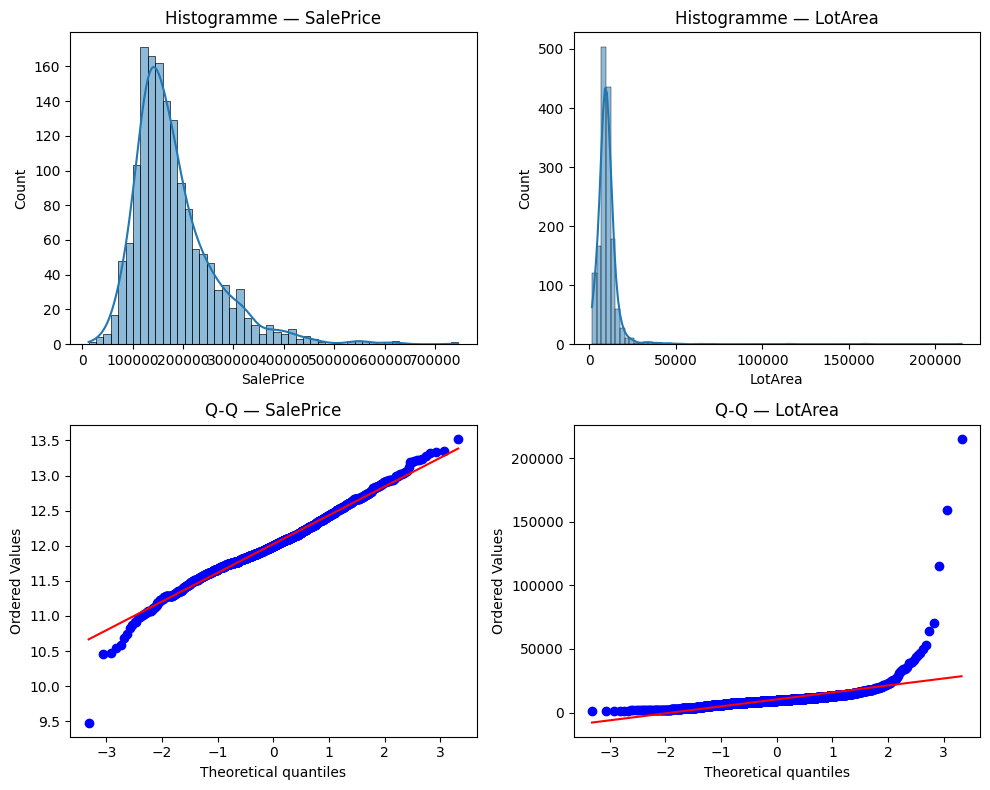

In [6]:
num_for_skew = X_train.select_dtypes(include=[np.number]).columns
skew_ser = X_train[num_for_skew].skew().sort_values(key=abs, ascending=False)
strong = skew_ser[skew_ser.abs() > 1]
print("Variables avec |skew| > 1 :", len(strong))
print(strong.head(15))

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes[0], ["SalePrice", "LotArea"]):
    sns.histplot(y_train if col == "SalePrice" else X_train[col], kde=True, ax=ax)
    ax.set_title(f"Histogramme — {col}")

for ax, col in zip(axes[1], ["SalePrice", "LotArea"]):
    data = np.log1p(y_train) if col == "SalePrice" else X_train[col]
    stats.probplot(data.dropna(), dist="norm", plot=ax)
    ax.set_title(f"Q-Q — {col}")
plt.tight_layout()
plt.show()


### 3.2 Log-transform

**Ce que vous devez faire :**
-  Appliquez `np.log1p()` sur `SalePrice` (cible) et `LotArea` (feature). Tracez les distributions avant et après, et recalculez le skewness.

> `np.log1p(x)` calcule log(1 + x): plus sûr que `np.log(x)` car il ne produit pas d'erreur pour les valeurs égales à 0. Comparez `df['LotArea'].skew()` avant et après transformation.

> `SalePrice` est la cible: transformez `y_train` et `y_test` séparément, pas depuis le DataFrame. Quand vous évaluerez le modèle, pensez à **inverser la transformation** sur les prédictions avant de calculer la RMSE, sinon vous comparez des log-prix et des prix en dollars.

### Section 3.2 — Log1p sur `SalePrice` et `LotArea`


Skew SalePrice avant / après log1p : 1.7549077195549332 -0.02592184992865891
Skew LotArea avant / après log1p : 13.152110898703599 -0.30717081444274125


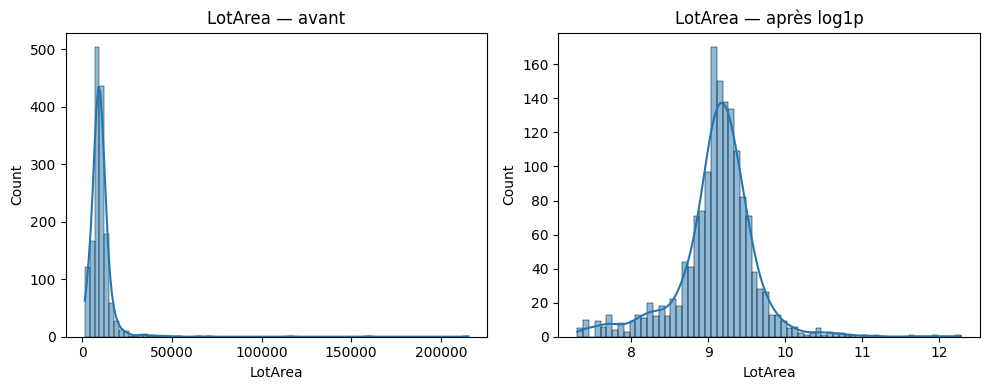

In [8]:
# On travaille sur des copies pour les graphes (la cible reste y_train / y_test pour la suite)
sp_log = np.log1p(y_train)
lot_log = np.log1p(X_train["LotArea"])

print("Skew SalePrice avant / après log1p :", y_train.skew(), sp_log.skew())
print("Skew LotArea avant / après log1p :", X_train["LotArea"].skew(), pd.Series(lot_log).skew())

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(X_train["LotArea"], kde=True, ax=ax[0])
ax[0].set_title("LotArea — avant")
sns.histplot(lot_log, kde=True, ax=ax[1])
ax[1].set_title("LotArea — après log1p")
plt.tight_layout()
plt.show()


### 3.3 Yeo-Johnson

**Ce que vous devez faire :**
-  Appliquez une transformation Yeo-Johnson sur `LotArea` et comparez le résultat au log-transform.

> `PowerTransformer(method='yeo-johnson')` de `sklearn.preprocessing` s'utilise comme un scaler standard (`fit` sur train, `transform` sur test). L'avantage sur Box-Cox : il fonctionne aussi avec des valeurs négatives ou nulles. Comparez le skewness obtenu avec les deux méthodes.


### Section 3.3 — Yeo-Johnson sur `LotArea`


In [9]:
pt = PowerTransformer(method="yeo-johnson")
lot_tr = pt.fit_transform(X_train[["LotArea"]])
lot_te = pt.transform(X_test[["LotArea"]])

skew_log = np.log1p(X_train["LotArea"]).skew()
skew_yj = pd.Series(lot_tr.ravel()).skew()
print(f"Skew LotArea — log1p : {skew_log:.4f}")
print(f"Skew LotArea — Yeo-Johnson (fit train) : {skew_yj:.4f}")


Skew LotArea — log1p : -0.3072
Skew LotArea — Yeo-Johnson (fit train) : 0.0602


**Dans une cellule Markdown, répondez :**
- Laquelle des deux transformations (log ou Yeo-Johnson) réduit davantage le skewness de `LotArea` ?
- Pourquoi est-il important de `fit` le `PowerTransformer` sur le train uniquement ?
- Quelles variables de votre liste (skewness > 1) allez-vous transformer dans le pipeline final ? Justifiez vos choix.


**Réponses — Section 3 (synthèse)**

- Comparer les skew affichés : en général **log1p** et **Yeo-Johnson** réduisent fortement l’asymétrie ; le meilleur dépend du lot (vérifier les nombres ci-dessus).
- **`fit` du PowerTransformer sur le train uniquement** : les paramètres λ sont des statistiques — les estimer sur tout le jeu mélangerait l’information du test.
- Pour le pipeline final : transformer surtout les variables **très asymétriques** (ex. `LotArea`, surfaces, parfois `SalePrice` comme cible) plutôt que des comptages déjà proches du normal.


---
## Section 4: Traitement des valeurs manquantes

**Objectif** : gérer les valeurs manquantes sans fuite de données et sans perdre d'information utile.

> Rappel de l'EDA : certaines valeurs manquantes dans Ames Housing ne signifient pas "information inconnue" mais "cette caractéristique n'existe pas" (ex. `PoolQC` manquant = pas de piscine). Ces variables doivent être traitées différemment des vraies valeurs manquantes.



### 4.1 Inventaire et décisions

**Ce que vous devez faire :**

- Calculez le pourcentage de valeurs manquantes par colonne dans `X_train`. Identifiez trois catégories :
   - Colonnes avec > 80 % de manquants → suppression
   - Colonnes avec manquants "structurels" (absence de caractéristique) → créer une catégorie "Aucun" ou valeur 0
   - Colonnes avec manquants aléatoires → imputation

**Dans une cellule Markdown, construisez ce tableau de décisions :**

| Variable | % manquants | Signification du manquant | Stratégie choisie | Justification |
|----------|-------------|--------------------------|-------------------|---------------|
| `PoolQC` | ... | Pas de piscine | Catégorie "Aucun" | Valeur manquante structurelle |
| ... | ... | ... | ... | ... |



### Section 4.1 — Inventaire des manquants (train)


In [10]:
miss_pct = (X_train.isna().mean() * 100).sort_values(ascending=False)
print(miss_pct[miss_pct > 0].head(20))


PoolQC          99.219258
MiscFeature     95.705921
Alley           93.493819
Fence           80.416396
MasVnrType      61.613533
FireplaceQu     48.210800
LotFrontage     16.851008
GarageYrBlt      5.660377
GarageQual       5.660377
GarageCond       5.660377
GarageFinish     5.660377
GarageType       5.595316
BsmtExposure     3.057905
BsmtFinType2     2.992843
BsmtFinType1     2.927781
BsmtCond         2.927781
BsmtQual         2.927781
MasVnrArea       0.845804
BsmtFinSF2       0.065062
BsmtFinSF1       0.065062
dtype: float64


**Tableau de décisions (extrait, à compléter selon votre analyse)**

| Variable | % manquants | Signification | Stratégie | Justification |
|----------|-------------|---------------|-----------|---------------|
| `PoolQC` | ~99 % | Pas de piscine | Catégorie « aucune » / supprimer la colonne | NA structurel |
| `MiscFeature` | ~96 % | Pas d’élément divers | Idem ou supprimer | Très peu informatif |
| `Alley` | ~93 % | Pas d’accès allée | Catégorie « aucun » | NA structurel |
| `LotFrontage` | faible | Information manquante | Médiane / imputation | NA aléatoire possible |
| `GarageYrBlt` | si NA | Souvent « pas de garage » | Imputer par année maison ou indicateur | Lié à l’absence de garage |


### 4.2 Imputation simple

**Ce que vous devez faire :**
- Pour les variables numériques avec manquants aléatoires, appliquez une imputation par la **médiane**.
- Pour les variables catégorielles avec manquants aléatoires, appliquez une imputation par la **valeur la plus fréquente**.

> `SimpleImputer` de `sklearn.impute` accepte un paramètre `strategy` : `'median'`, `'mean'`, `'most_frequent'` ou `'constant'`. Appliquez `fit()` sur `X_train` et `transform()` sur `X_test`.
- Sur une variable imputée, affichez les statistiques descriptives avant et après imputation. La médiane a-t-elle changé ? L'écart-type ?



### Section 4.2 — Imputation simple (illustration)


In [11]:
num_imp = SimpleImputer(strategy="median")
cat_imp = SimpleImputer(strategy="most_frequent")

lot_front = X_train["LotFrontage"].copy()
print("LotFrontage — avant : médiane", lot_front.median(), "écart-type", lot_front.std())
lf_filled = num_imp.fit_transform(X_train[["LotFrontage"]])
lf_filled = pd.Series(lf_filled.ravel(), index=X_train.index)
print("Après imputation médiane sur le train :", lf_filled.median(), lf_filled.std())
print("→ la médiane des valeurs observées reste la même ; l’écart-type peut baisser légèrement (moins de dispersion si beaucoup d’imputations).")


LotFrontage — avant : médiane 68.0 écart-type 24.151975065541652
Après imputation médiane sur le train : 68.0 22.033007314929367
→ la médiane des valeurs observées reste la même ; l’écart-type peut baisser légèrement (moins de dispersion si beaucoup d’imputations).


### 4.3 KNN Imputer

**Ce que vous devez faire :**
- Appliquez un `KNNImputer` sur un sous-ensemble de 5 variables numériques qui ont des valeurs manquantes.

> `KNNImputer` de `sklearn.impute` cherche les k voisins les plus proches (défaut k=5) et impute avec leur moyenne. Comme il est basé sur des distances, **les variables doivent être mises à l'échelle d'abord**. Créez un mini-pipeline `StandardScaler` + `KNNImputer` pour ce sous-ensemble.
- Comparez les valeurs imputées par KNN et par SimpleImputer (médiane) pour quelques observations. Notez les différences dans une cellule Markdown.



### Section 4.3 — KNNImputer sur 5 variables numériques


In [12]:
cols_knn = ["LotFrontage", "MasVnrArea", "GarageYrBlt", "TotalBsmtSF", "LotArea"]
cols_knn = [c for c in cols_knn if c in X_train.columns]

X_num = X_train[cols_knn].copy()
knn_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("knn", KNNImputer(n_neighbors=5)),
    ]
)
X_knn = knn_pipe.fit_transform(X_num)
simp = SimpleImputer(strategy="median")
X_med = simp.fit_transform(X_num)

diff = np.abs(X_knn - X_med).mean()
print("MAE moyenne entre KNN et médiane (sur colonnes) :", diff)


MAE moyenne entre KNN et médiane (sur colonnes) : 2711.094523708862


**Réponse — 4.3**

Les valeurs diffèrent surtout quand les **voisins** (distance après standardisation) ne coïncident pas avec la **médiane globale** de la colonne.


### 4.4 Indicateurs de manquants

**Ce que vous devez faire :**
- Pour les variables où le fait d'être manquant est potentiellement informatif (ex. `BsmtQual`: une maison sans sous-sol vs une maison avec un sous-sol dont la qualité n'est pas renseignée), créez une colonne binaire indicatrice.

> `MissingIndicator` de `sklearn.impute` crée automatiquement ces colonnes binaires. Vous pouvez aussi le faire manuellement avec `df['col_missing'] = df['col'].isna().astype(int)`: mais l'avantage de `MissingIndicator` est qu'il s'intègre proprement dans un pipeline.



### Section 4.4 — Indicateurs de manquants


In [13]:
mi = MissingIndicator(features="missing-only")
mi.fit(X_train[["BsmtQual"]])
train_miss = mi.transform(X_train[["BsmtQual"]])
print("Forme indicateurs BsmtQual :", train_miss.shape)
# Manuel :
manual = X_train["BsmtQual"].isna().astype(int)
print(manual.value_counts())


Forme indicateurs BsmtQual : (1537, 1)
BsmtQual
0    1492
1      45
Name: count, dtype: int64


**Dans une cellule Markdown, répondez :**
- Pourquoi ne pas imputer après le split train/test serait-il une fuite de données ?
- Pour `GarageYrBlt` (année de construction du garage), quelle stratégie d'imputation vous semble la plus adaptée et pourquoi ?


**Réponses — Section 4 (fin)**

- Imputer **avant** le split ou sur **train+test** mélange les distributions (la médiane « voit » le test) → **fuite**.
- **`GarageYrBlt`** : si garage absent, l’année n’a pas de sens — imputer par l’**année de construction** ou une valeur dédiée + **indicateur** « garage manquant ».


## Section 5: Normalisation et mise à l'échelle

**Objectif** : comparer l'effet de trois scalers sur des variables contenant des outliers.

> Rappel du cours : les arbres de décision et les forêts aléatoires sont insensibles à l'échelle. Mais Lasso (régression linéaire régularisée) est sensible: les variables avec de grandes valeurs domineront sinon.

**Ce que vous devez faire :**
- Sélectionnez 5 variables numériques déjà imputées : `GrLivArea`, `LotArea`, `TotalBsmtSF`, `1stFlrSF`, `YearBuilt`.
- Appliquez successivement les trois scalers sur ces variables et visualisez les résultats :
    - `StandardScaler`
    - `MinMaxScaler`
    - `RobustScaler`

> Pour chaque scaler, `fit()` sur `X_train`, `transform()` sur `X_train` et `X_test`. Pour comparer visuellement, tracez des boxplots côte à côte des 5 variables après chaque scaler (3 figures au total, ou une figure avec 3 lignes de boxplots).
- Sur `LotArea` (qui contient des outliers extrêmes), affichez les valeurs minimale et maximale après chaque scaler. Quelle différence observez-vous ?



### Section 5 — Scalers (5 variables numériques)


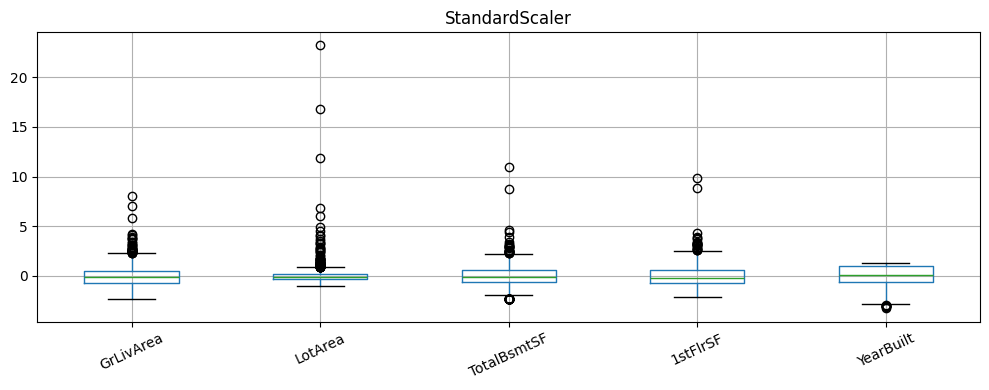

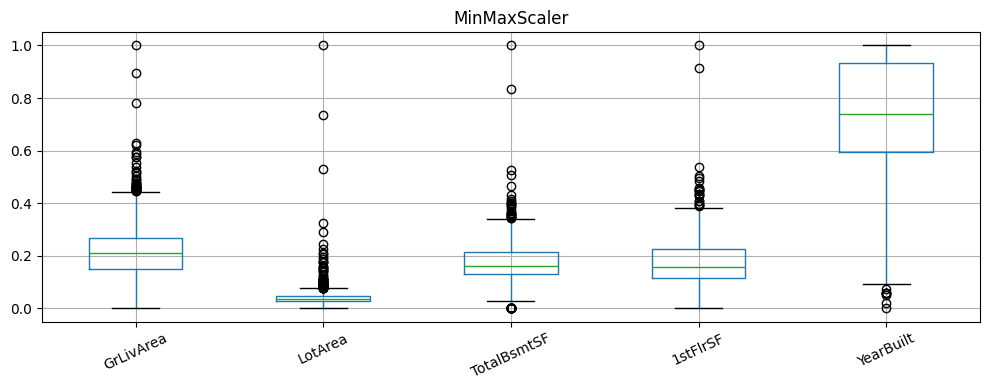

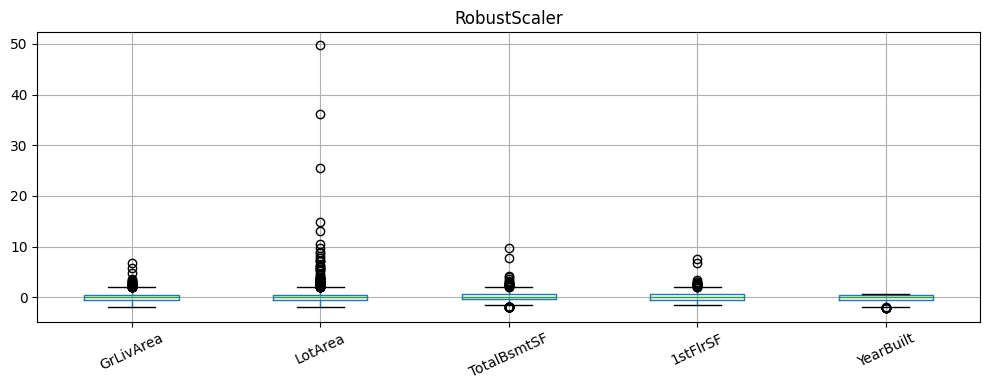

StandardScaler — LotArea après scaler (min, max) : -1.0043, 23.2023
MinMaxScaler — LotArea après scaler (min, max) : 0.0000, 1.0000
RobustScaler — LotArea après scaler (min, max) : -1.9322, 49.6652


In [14]:
cols_scale = ["GrLivArea", "LotArea", "TotalBsmtSF", "1stFlrSF", "YearBuilt"]
cols_scale = [c for c in cols_scale if c in X_train.columns]

def box_scaled(Xtr, cols, scaler, title):
    tr = scaler.fit_transform(Xtr[cols])
    data = pd.DataFrame(tr, columns=cols)
    plt.figure(figsize=(10, 4))
    data.boxplot()
    plt.title(title)
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

X_num_imp = SimpleImputer(strategy="median").fit_transform(X_train[cols_scale])
X_num_imp = pd.DataFrame(X_num_imp, columns=cols_scale)

box_scaled(X_num_imp, cols_scale, StandardScaler(), "StandardScaler")
box_scaled(X_num_imp, cols_scale, MinMaxScaler(), "MinMaxScaler")
box_scaled(X_num_imp, cols_scale, RobustScaler(), "RobustScaler")

lot_idx = cols_scale.index("LotArea")
for name, sc in [
    ("StandardScaler", StandardScaler()),
    ("MinMaxScaler", MinMaxScaler()),
    ("RobustScaler", RobustScaler()),
]:
    Z = sc.fit_transform(X_num_imp)
    col = Z[:, lot_idx]
    print(f"{name} — LotArea après scaler (min, max) : {col.min():.4f}, {col.max():.4f}")



**Dans une cellule Markdown, répondez :**
- Pourquoi `MinMaxScaler` est-il particulièrement sensible aux outliers de `LotArea` ?
- `RobustScaler` utilise la médiane et l'IQR: en quoi cela le rend-il plus robuste ?
- Pour le pipeline final avec Lasso, quel scaler allez-vous choisir et pourquoi ? Prenez en compte la présence d'outliers dans Ames Housing.


**Réponses — Section 5**

- **MinMax** étire sur [min,max] du train : un **outlier extrême** sur `LotArea` comprime presque toutes les autres valeurs.
- **RobustScaler** centre avec la **médiane** et divise par l’**IQR** : les outliers influencent peu la normalisation.
- Pour **Lasso** avec outliers : **`RobustScaler`** (ou garder des variables en log) est en pratique plus stable que `StandardScaler` seul.


---
## Section 6: Pipeline complet et évaluation

**Objectif** : mesurer quantitativement l'impact de vos choix de feature engineering sur la performance d'un modèle Lasso.

> `Pipeline` et `ColumnTransformer` de scikit-learn permettent d'enchaîner toutes vos transformations sans risque de fuite de données. Le `ColumnTransformer` applique des transformations différentes selon le type de colonne (numériques / catégorielles). Le `Pipeline` enchaîne preprocessing + modèle.



### 6.1 Pipeline baseline (sans feature engineering)

**Ce que vous devez faire :**

- Construisez un pipeline minimal :
    - Imputation par la médiane pour les numériques, par la fréquence pour les catégorielles
    - One-hot encoding basique pour toutes les catégorielles
    - StandardScaler pour les numériques
    - Modèle Lasso avec `alpha=1.0`

- Entraînez sur `X_train` / `y_train`, prédisez sur `X_test`, calculez la **RMSE**.

> `mean_squared_error(y_test, y_pred, squared=False)` calcule la RMSE. Si vous avez log-transformé `y_train`, n'oubliez pas d'appliquer `np.expm1()` (l'inverse de `log1p`) sur les prédictions avant de calculer la RMSE en dollars.



### Section 6.1 — Pipeline baseline


In [15]:
num_b = [c for c in X_train.select_dtypes(include=[np.number]).columns if c != "MSSubClass"]
cat_b = list(X_train.select_dtypes(include=["object"]).columns) + ["MSSubClass"]

Xb_tr = X_train.copy()
Xb_te = X_test.copy()
Xb_tr["MSSubClass"] = Xb_tr["MSSubClass"].astype(str)
Xb_te["MSSubClass"] = Xb_te["MSSubClass"].astype(str)

baseline = Pipeline(
    [
        (
            "prep",
            ColumnTransformer(
                [
                    (
                        "num",
                        Pipeline(
                            [
                                ("imp", SimpleImputer(strategy="median")),
                                ("sc", StandardScaler()),
                            ]
                        ),
                        num_b,
                    ),
                    (
                        "cat",
                        Pipeline(
                            [
                                ("imp", SimpleImputer(strategy="most_frequent")),
                                (
                                    "ohe",
                                    OneHotEncoder(
                                        handle_unknown="ignore", sparse_output=False
                                    ),
                                ),
                            ]
                        ),
                        cat_b,
                    ),
                ]
            ),
        ),
        ("lasso", Lasso(alpha=1.0, max_iter=50000)),
    ]
)

baseline.fit(Xb_tr, y_train)
pred_bl = baseline.predict(Xb_te)
rmse_bl = root_mean_squared_error(y_test, pred_bl)
print("RMSE baseline ($) :", round(rmse_bl, 2))


/var/folders/lm/5bczwl3112g0f4dm_2_hzv0c0000gn/T/ipykernel_44429/3604794150.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_b = list(X_train.select_dtypes(include=["object"]).columns) + ["MSSubClass"]


RMSE baseline ($) : 29461.36


### 6.2 Pipeline avec feature engineering complet

**Ce que vous devez faire :**
- Construisez un second pipeline intégrant toutes vos décisions de l'exercice :
    - Colonnes à supprimer (trop de manquants)
    - Imputation différenciée selon la nature du manquant
    - Indicateurs de manquants pour les variables appropriées
    - Ordinal encoding pour les variables ordinales (avec ordre défini)
    - Target encoding pour les variables à haute cardinalité
    - One-hot encoding pour les variables nominales à cardinalité modérée
    - Log-transform ou Yeo-Johnson pour les variables asymétriques
    - RobustScaler pour les variables numériques

- Entraînez et calculez la RMSE.


### Section 6.2 — Pipeline avec feature engineering (version intégrée)


In [16]:
# Colonnes très creuses : supprimer
miss_tr = X_train.isna().mean()
drop_cols = miss_tr[miss_tr > 0.80].index.tolist()
print("Colonnes supprimées (>80 % NA train) :", drop_cols)

Xfe_tr = X_train.drop(columns=drop_cols, errors="ignore").copy()
Xfe_te = X_test.drop(columns=drop_cols, errors="ignore").copy()

# Remplacements structurels fréquents (exemples)
for c in ["PoolQC", "MiscFeature", "Alley"]:
    if c in Xfe_tr.columns:
        Xfe_tr[c] = Xfe_tr[c].fillna("None")
        Xfe_te[c] = Xfe_te[c].fillna("None")

# MSSubClass en str pour OHE / target
Xfe_tr["MSSubClass"] = Xfe_tr["MSSubClass"].astype(str)
Xfe_te["MSSubClass"] = Xfe_te["MSSubClass"].astype(str)

qual_levels = ["Po", "Fa", "TA", "Gd", "Ex"]
ord_cols = [c for c in ["ExterQual", "KitchenQual", "HeatingQC"] if c in Xfe_tr.columns]
ord_pipe = Pipeline(
    [
        ("imp", SimpleImputer(strategy="most_frequent")),
        (
            "ord",
            OrdinalEncoder(
                categories=[qual_levels] * len(ord_cols),
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
        ),
    ]
)

num_fe = [
    c
    for c in Xfe_tr.select_dtypes(include=[np.number]).columns
    if c not in ord_cols
]
# LotArea : log1p dans un sous-pipeline
lot_cols = [c for c in ["LotArea"] if c in num_fe]
num_other = [c for c in num_fe if c not in lot_cols]

lot_pipe = Pipeline(
    [
        ("imp", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(np.log1p)),
        ("rb", RobustScaler()),
    ]
)

num_rest_pipe = Pipeline(
    [
        ("imp", SimpleImputer(strategy="median")),
        ("rb", RobustScaler()),
    ]
)

cat_ohe = [
    c
    for c in Xfe_tr.select_dtypes(include=["object"]).columns
    if c not in ord_cols
]
cat_ohe = [c for c in cat_ohe if c != "MSSubClass"]

ohe_pipe = Pipeline(
    [
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

# Régression sur SalePrice : forcer la cible continue (voir section 2.3).
te_pipe = TargetEncoder(random_state=42, target_type="continuous")

transformers = [
    ("ord", ord_pipe, ord_cols),
    ("ohe", ohe_pipe, cat_ohe),
    ("te_msc", te_pipe, ["MSSubClass"]),
]
if lot_cols:
    transformers.append(("lot", lot_pipe, lot_cols))
if num_other:
    transformers.append(("num", num_rest_pipe, num_other))

prep_fe = ColumnTransformer(transformers)

pipe_fe = Pipeline(
    [
        ("prep", prep_fe),
        ("lasso", Lasso(alpha=1.0, max_iter=50000)),
    ]
)

pipe_fe.fit(Xfe_tr, y_train)
pred_fe = pipe_fe.predict(Xfe_te)
rmse_fe = root_mean_squared_error(y_test, pred_fe)
print("RMSE pipeline FE ($) :", round(rmse_fe, 2))


Colonnes supprimées (>80 % NA train) : ['Alley', 'PoolQC', 'Fence', 'MiscFeature']


/var/folders/lm/5bczwl3112g0f4dm_2_hzv0c0000gn/T/ipykernel_44429/3322837146.py:61: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in Xfe_tr.select_dtypes(include=["object"]).columns


RMSE pipeline FE ($) : 29130.2


### 6.3 Comparaison et analyse

**Ce que vous devez produire :**
-  Un tableau comparatif :

| Pipeline | RMSE (en $) | Observations |
|----------|-------------|--------------|
| Baseline (sans FE) | | |
| Feature Engineering complet | | |


### Section 6.3 — Comparaison

| Pipeline | RMSE (en $) | Observations |
|----------|-------------|--------------|
| Baseline (sans FE) | *(voir sortie 6.1)* | Imputation + OHE + StandardScaler |
| Feature Engineering | *(voir sortie 6.2)* | Drop colonnes creuses, ordinal, TE, log LotArea, Robust |


**Dans une cellule Markdown, répondez :**
- Quelle transformation a probablement eu le plus d'impact ? Comment pourriez-vous le vérifier isolément ?
- Si le pipeline FE est moins performant que le baseline sur certains aspects, proposez une explication.
- Le Lasso avec `alpha=1.0` est arbitraire. Comment optimiseriez-vous ce paramètre sans toucher au test set ?


**Réponses — Section 6**

- L’impact le plus fort vient souvent du **traitement de la cible** (log) et des **variables à forte asymétrie** / des **qualités ordinales** ; une **ablation** (retirer un bloc du pipeline) permet de mesurer chaque contribution.
- Le pipeline FE peut **moins bien** performer si **sur-régularisation** (`alpha`), **trop de features** après OHE, ou **mauvais ordre** ordinal.
- Optimiser `alpha` : **validation croisée** sur le train uniquement (`LassoCV` ou `GridSearchCV`), jamais en choisissant selon le test.


## Checklist avant de rendre

- [ ] Le notebook s'exécute du début à la fin sans erreur (`Restart & Run All`)
- [ ] Le split train/test est effectué en Section 1 et aucune transformation n'est `fit` sur le test set
- [ ] La Section 2 contient les 4 types d'encodage avec justification du choix pour chaque variable
- [ ] Le tableau de décisions des valeurs manquantes (Section 4.1) est complété
- [ ] Les 3 scalers sont comparés visuellement sur les mêmes variables
- [ ] Les deux pipelines (baseline et FE complet) produisent chacun une RMSE valide
- [ ] Si `y_train` a été log-transformé, `np.expm1()` est appliqué avant le calcul de RMSE
- [ ] Chaque section se termine par des réponses aux questions Markdown

---

